In [ ]:
import numpy as np
import pandas as pd
import torch
import torch.optim as optim
import torch.nn as nn
import os
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from matplotlib import pyplot as plt
import torchvision.transforms as transforms

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install livelossplot --quiet
from livelossplot import PlotLosses

In [ ]:
class LandmarkDataset(Dataset):
    def __init__(self, csv_name, transform=None):
        self.csv_dir = '/content/drive/MyDrive/proj646/data/'
        self.img_dir = '/content/drive/MyDrive/proj646/data/cepha400/cepha400/'
        self.csv_file = csv_name
        self.transform = transform
        self.csv_file = pd.read_csv(os.path.join(self.csv_dir, self.csv_file))

        self.images = []
        self.masks = []

        # set width of the mask to be created around each landmark point
        self.w = 20

        for row in self.csv_file.values:
            img_name, img_landmarks = row[0], row[1:]

            img_path = os.path.join(self.img_dir, img_name)
            # convert to grayscale grayscale format, with values in [0-black, 255-white]
            image = Image.open(img_path).convert('L')
            # TODO: do we need to normalize here?? [0-black, 1-white]
            image = np.array(image) / 255

            mask = np.zeros((image.shape[0], image.shape[1]), dtype=np.uint8)
            for i in range(0, len(img_landmarks), 2):
                x, y = img_landmarks[i], img_landmarks[i+1]
                # create a square of width 2w
                mask[y-self.w:y+self.w, x-self.w:x+self.w] = 1

            # convert numpy arrays to PIL Image objects
            image = Image.fromarray((image * 255).astype(np.uint8))
            mask = Image.fromarray(mask)

            # resize image and mask to 256x256
            image = image.resize((256, 256))
            mask = mask.resize((256, 256))

            self.images.append(image)
            self.masks.append(mask)

    def __len__(self):
        return len(self.images)
    
    def __getitem__(self, idx):
        image = self.images[idx]
        mask = self.masks[idx]

        # use same transform to ensure image and mask have same size and position
        if self.transform:
            image = self.transform(image)
            mask = self.transform(mask)
            
        return image, mask




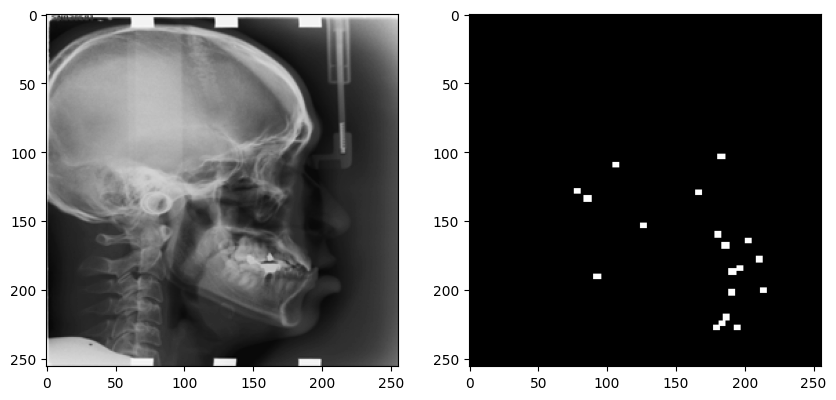

In [ ]:
trainset = LandmarkDataset('train_senior.csv')
image, mask = trainset[0]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))
ax1.imshow(image, cmap='gray')
ax2.imshow(mask, cmap='gray')
plt.show()

In [ ]:
print(type(image))
print(type(mask))

<class 'PIL.Image.Image'>
<class 'PIL.Image.Image'>


In [ ]:
# dataloader
transform = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomCrop(size=(256, 256)),
    transforms.ToTensor(),
    # transforms.Normalize(mean=[0.5], std=[0.5])
])

trainset = LandmarkDataset(csv_name='train_senior.csv', transform=transform)
testset = LandmarkDataset(csv_name='test1_senior.csv', transform=transform)

# choose a hyperparameter:
batch_size = 10

train_loader = DataLoader(trainset, batch_size, shuffle=True)
test_loader = DataLoader(testset, batch_size, shuffle=False)


In [ ]:
for batch_idx, (images, masks) in enumerate(train_loader):
    print(f'Batch {batch_idx}: Images shape = {images.shape}, Masks shape = {masks.shape}')
    if batch_idx == 1:
      # print(images)
      print(masks) # this should not be -1 ???

Batch 0: Images shape = torch.Size([10, 1, 256, 256]), Masks shape = torch.Size([10, 1, 256, 256])
Batch 1: Images shape = torch.Size([10, 1, 256, 256]), Masks shape = torch.Size([10, 1, 256, 256])
tensor([[[[0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          ...,
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.]]],


        [[[0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          ...,
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.]]],


        [[[0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          ...,
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0.

In [ ]:
# unet

class UNet(nn.Module):
    def __init__(self, in_channels, out_channels):
        super(UNet, self).__init__()

        def conv_block(in_channels, out_channels):
            return nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
                nn.ReLU(inplace=True),
                nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
                nn.ReLU(inplace=True)
            )

        def upconv_block(in_channels, out_channels):
            return nn.Sequential(
                nn.ConvTranspose2d(in_channels, out_channels, kernel_size=2, stride=2),
                nn.ReLU(inplace=True)
            )

        self.encoder1 = conv_block(in_channels, 64)
        self.encoder2 = nn.Sequential(
            nn.MaxPool2d(kernel_size=2, stride=2),
            conv_block(64, 128)
        )

        self.middle = nn.Sequential(
            nn.MaxPool2d(kernel_size=2, stride=2),
            conv_block(128, 256)
        )

        self.upconv1 = upconv_block(256, 128)
        self.decoder1 = conv_block(256, 128)
        
        self.upconv2 = upconv_block(128, 64)
        self.decoder2 = conv_block(128, 64)

        self.final = nn.Conv2d(64, out_channels, kernel_size=1)

    def forward(self, x):
        enc1 = self.encoder1(x)
        enc2 = self.encoder2(enc1)
        middle = self.middle(enc2)

        up1 = self.upconv1(middle)
        dec1 = torch.cat([up1, enc2], dim=1)
        dec1 = self.decoder1(dec1)
        
        up2 = self.upconv2(dec1)
        dec2 = torch.cat([up2, enc1], dim=1)
        dec2 = self.decoder2(dec2)

        out = self.final(dec2)
        return out


In [ ]:
unet = UNet(in_channels=1, out_channels=1)


In [ ]:
# criterion = nn.BCEWithLogitsLoss()
# optimizer = torch.optim.Adam(unet.parameters(), lr=1e-3)

# # Training loop
# num_epochs = 20
# for epoch in range(num_epochs):
#     for batch_idx, (images, masks) in enumerate(train_loader):
#         outputs = unet(images)

#         loss = criterion(outputs, masks)
#         optimizer.zero_grad()
#         loss.backward()

#         optimizer.step()

#         print(f"Epoch [{epoch+1}/{num_epochs}], Batch [{batch_idx+1}/{len(dataloader)}], Loss: {loss.item()}")


#  a few results:
# Epoch [1/20], Batch [1/5], Loss: 0.5697385668754578
# Epoch [1/20], Batch [2/5], Loss: 0.44543784856796265
# Epoch [1/20], Batch [3/5], Loss: 0.21566450595855713
# Epoch [1/20], Batch [4/5], Loss: -0.40141308307647705
# Epoch [1/20], Batch [5/5], Loss: -2.5993547439575195
# Epoch [2/20], Batch [1/5], Loss: -13.260258674621582
# Epoch [2/20], Batch [2/5], Loss: -65.69992065429688
# Epoch [2/20], Batch [3/5], Loss: -301.8116149902344
# Epoch [2/20], Batch [4/5], Loss: -1226.7635498046875
# Epoch [2/20], Batch [5/5], Loss: -4602.57080078125
# Epoch [3/20], Batch [1/5], Loss: -14930.189453125
# Epoch [3/20], Batch [2/5], Loss: -46647.734375
# Epoch [3/20], Batch [3/5], Loss: -132752.296875


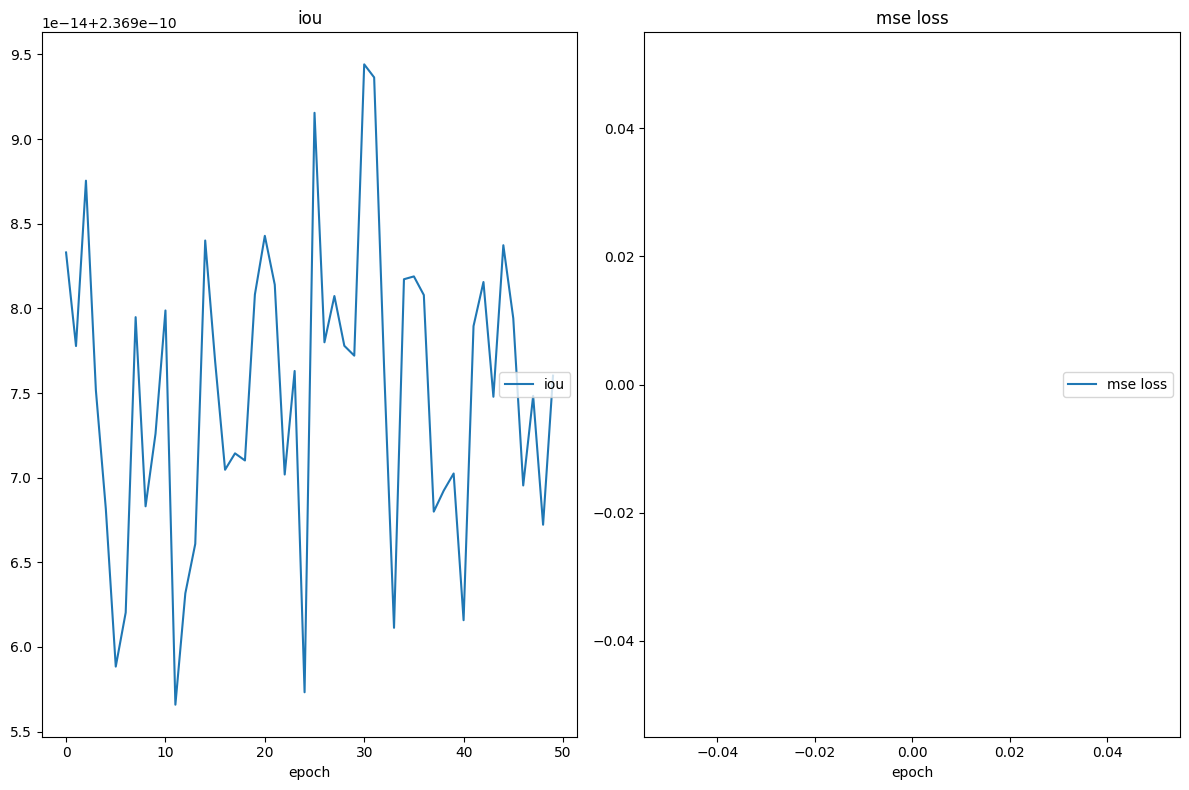

iou
	iou              	 (min:    0.000, max:    0.000, cur:    0.000)
mse loss
	mse loss         	 (min:      nan, max:      nan, cur:      nan)


In [ ]:
# try Intersection over Union (IoU) instead of accuracy:

import torch.optim as optim
from torch.nn import MSELoss
from torch.autograd import Variable
from livelossplot import PlotLosses
import numpy as np

def iou_score(output, target):
    smooth = 1e-6
    output = output.bool()
    target = target.bool()
    intersection = (output & target).float().sum()
    union = (output | target).float().sum()
    iou = (intersection + smooth) / (union + smooth)
    return iou.item()


device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
unet.to(device)

criterion = MSELoss()
optimizer = optim.Adam(unet.parameters(), lr=0.001)

num_epochs = 50

liveloss = PlotLosses()
for epoch in range(num_epochs):
    logs = {}
    epoch_loss = 0
    epoch_iou = 0

    for i, (inputs, masks) in enumerate(train_loader):
        inputs, masks = inputs.to(device), masks.to(device)

        optimizer.zero_grad()
        outputs = unet(inputs)

        loss = criterion(outputs, masks)
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

        outputs = (torch.sigmoid(outputs) > 0.5).float()
        iou = iou_score(outputs, masks)
        epoch_iou += iou

    mean_loss = epoch_loss / len(train_loader)
    mean_iou = epoch_iou / len(train_loader)

    logs['mse loss'] = mean_loss
    logs['iou'] = mean_iou

    liveloss.update(logs)
    liveloss.send()


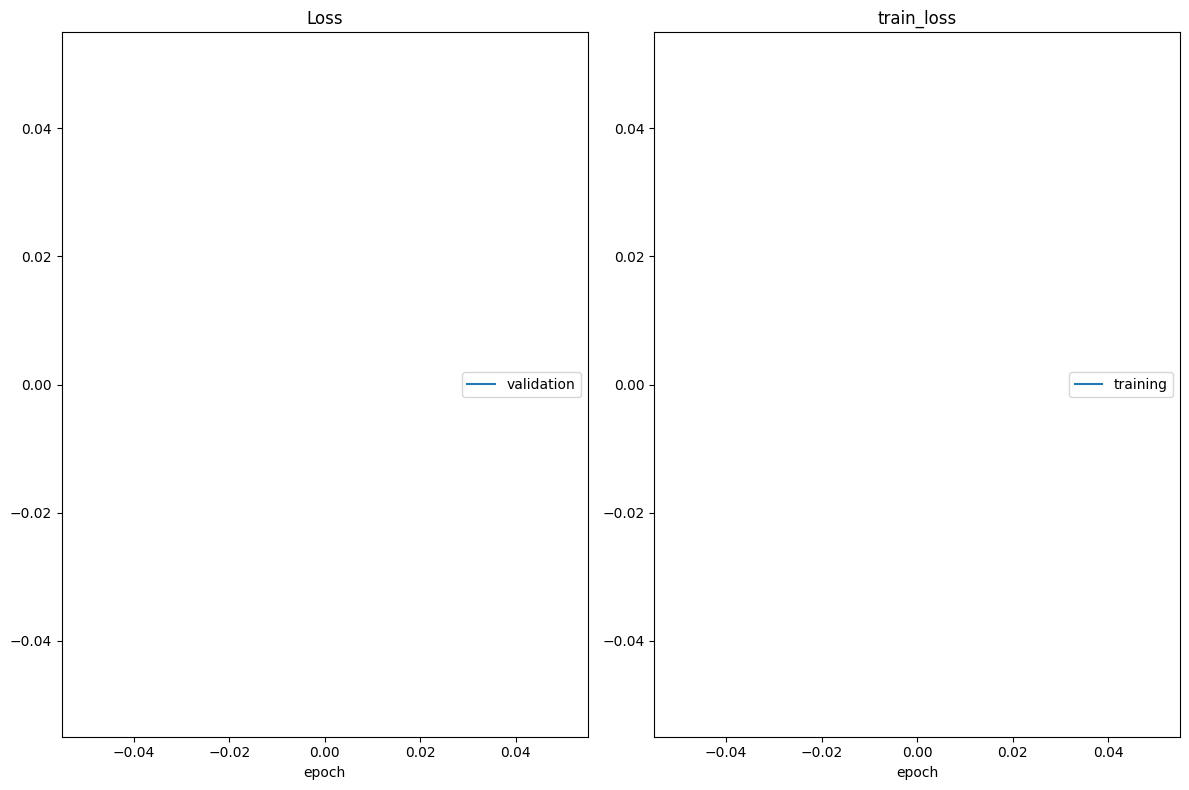

Loss
	validation       	 (min:      nan, max:      nan, cur:      nan)
train_loss
	training         	 (min:      nan, max:      nan, cur:      nan)


In [ ]:
import torch.optim as optim
from torch.autograd import Variable
from torch.utils.data import DataLoader
from livelossplot import PlotLosses
import torch.nn.functional as F

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
unet.to(device)

epochs = 100
learning_rate = 0.001

criterion = nn.MSELoss()
optimizer = optim.Adam(unet.parameters(), lr=learning_rate)
liveloss = PlotLosses()

# Training loop
for epoch in range(epochs):
    logs = {}
    running_loss = 0.0
    total_train = 0

    # Training
    unet.train()
    for i, data in enumerate(train_loader, 0):
        inputs, masks = data
        inputs, masks = Variable(inputs.to(device)), Variable(masks.to(device))
        optimizer.zero_grad()

        outputs = unet(inputs)
        loss = criterion(outputs, masks)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        total_train += 1

    train_loss = running_loss / total_train
    logs['train_loss'] = train_loss

    # Evaluation
    unet.eval()
    with torch.no_grad():
        running_loss = 0.0
        total_val = 0
        for i, data in enumerate(test_loader, 0):
            inputs, masks = data
            inputs, masks = Variable(inputs.to(device)), Variable(masks.to(device))

            outputs = unet(inputs)
            loss = criterion(outputs, masks)

            running_loss += loss.item()
            total_val += 1

        val_loss = running_loss / total_val
        logs['val_loss'] = val_loss

    # Update the plot
    liveloss.update(logs)
    liveloss.send()


In [ ]:
!pip install timm


In [ ]:
import torch
import torch.nn as nn
import timm

class CustomViT(nn.Module):
    def __init__(self, pretrained=True):
        super(CustomViT, self).__init__()
        self.vit = timm.create_model("vit_base_patch16_224", pretrained=pretrained, num_classes=0)
        
        # Change the patch embedding layer to accept 256x256 images with 1 channel
        self.vit.patch_embed = timm.models.vision_transformer.PatchEmbed(
            img_size=256, patch_size=16, in_chans=1, embed_dim=768
        )

        self.segmentation_head = nn.Sequential(
            nn.Linear(768, 256),  # 768 is the output size of vit_base_patch16_224
            nn.ReLU(),
            nn.Linear(256, 1)
        )

    def forward(self, x):
        features = self.vit(x)
        out = self.segmentation_head(features)
        return out

vit_model = CustomViT().to(device)


In [ ]:
import torch.optim as optim

# Set training parameters
epochs = 100
learning_rate = 0.001

# Choose loss function and optimizer
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(vit_model.parameters(), lr=learning_rate)

# Training loop
for epoch in range(epochs):
    running_loss = 0.0
    for i, data in enumerate(train_loader, 0):
        inputs, masks = data
        inputs, masks = inputs.to(device), masks.to(device)

        optimizer.zero_grad()

        outputs = vit_model(inputs)
        loss = criterion(outputs.view(-1), masks.view(-1))
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    # Print average loss for this epoch
    print(f"Epoch {epoch + 1}, Loss: {running_loss / (i + 1)}")

print("Finished Training")
